<a href="https://colab.research.google.com/github/1Suryaa/Shrimp_price_reconstruction_Time_series/blob/main/shimp_price_reconstruction_time_series_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn tensorflow ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import ruptures as rpt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
df = pd.read_csv('/content/precos_camaroes_completo.csv')

df.head()

,YearMonth,Aquaculture_Export_Dol,Aquaculture_whlsl_Dol,Capture_Export_Dol,Exchange_Rate
0,2013-08-01 00:00:00,6.123698,6.470519,15.459135,2.337382
1,2013-09-01 00:00:00,7.449545,6.946426,13.430200,2.269638
2,2013-10-01 00:00:00,6.889196,7.243747,14.597276,2.185359
3,2013-11-01 00:00:00,6.363534,6.456629,16.985128,2.290524
4,2013-12-01 00:00:00,6.615833,7.096768,15.828203,2.343455


In [ ]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Aquaculture_Export_Dol': 'AED',
    'Aquaculture_whlsl_Dol': 'AWD',
    'Capture_Export_Dol': 'WED',
    'Exchange_Rate': 'ER'
})

# Handle the ambiguous state where 'date' is both index and column
# This ensures a clean 'date' column before sorting and setting index
if 'date' in df.columns and df.index.name == 'date':
    df.drop(columns=['date'], inplace=True)

# Reset index if 'date' is currently the index. This converts the index 'date' into a column.
if df.index.name == 'date':
    df.reset_index(inplace=True)

# Ensure 'date' column is correctly created from 'YearMonth' and is of datetime type
if 'YearMonth' in df.columns:
    df['date'] = pd.to_datetime(df['YearMonth'])
    df.drop('YearMonth', axis=1, inplace=True) # Drop original YearMonth column
elif 'date' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['date']):
    # If YearMonth is gone, but 'date' column exists and is not datetime, convert it.
    df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

df.set_index('date', inplace=True)

df = df.interpolate(method='linear')

df.head()

,AED,AWD,WED,ER
date,,,,
2013-08-01,6.123698,6.470519,15.459135,2.337382
2013-09-01,7.449545,6.946426,13.430200,2.269638
2013-10-01,6.889196,7.243747,14.597276,2.185359
2013-11-01,6.363534,6.456629,16.985128,2.290524
2013-12-01,6.615833,7.096768,15.828203,2.343455


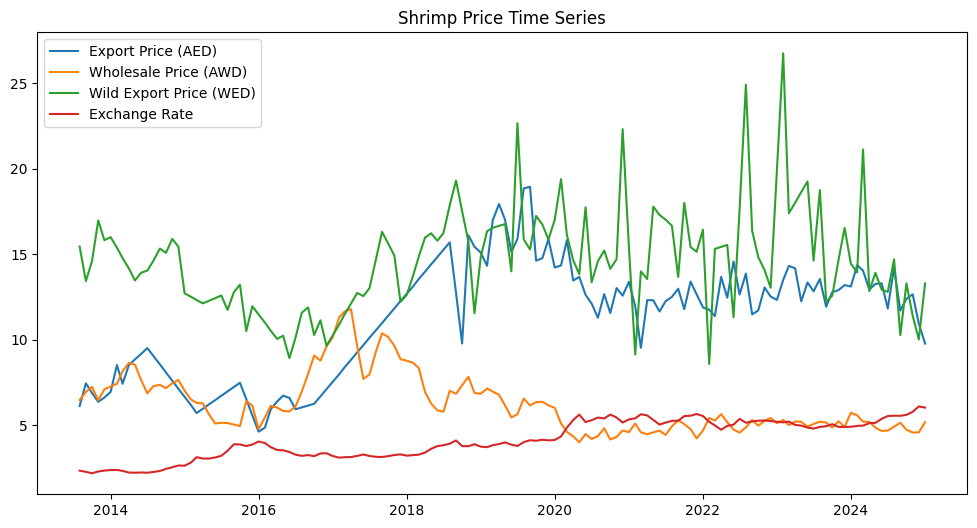

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['AED'], label='Export Price (AED)')
plt.plot(df['AWD'], label='Wholesale Price (AWD)')
plt.plot(df['WED'], label='Wild Export Price (WED)')
plt.plot(df['ER'], label='Exchange Rate')

plt.legend()
plt.title("Shrimp Price Time Series")
plt.show()

In [ ]:
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(df['AED'])

ADF Statistic: -1.5577492215260023
p-value: 0.504775116654873


In [ ]:
df['AED_diff'] = df['AED'].diff()

In [ ]:
df['rolling_mean_3'] = df['AED'].rolling(3).mean()
df['rolling_std_3'] = df['AED'].rolling(3).std()

df['lag1'] = df['AED'].shift(1)
df['lag2'] = df['AED'].shift(2)

df.dropna(inplace=True)

In [ ]:
train_size = int(len(df)*0.8)

train = df[:train_size]
test = df[train_size:]

In [ ]:
model = SARIMAX(
    train['AED'],
    exog=train[['AWD','WED','ER']],
    order=(1,1,0),
    seasonal_order=(1,0,1,12)
)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                                  AED   No. Observations:                  108
Model:             SARIMAX(1, 1, 0)x(1, 0, [1], 12)   Log Likelihood                -175.401
Date:                              Thu, 05 Mar 2026   AIC                            364.802
Time:                                      11:07:46   BIC                            383.511
Sample:                                  10-01-2013   HQIC                           372.386
                                       - 09-01-2022                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
AWD            0.0590      0.279      0.212      0.832      -0.487       0.605
WED           -0.05

In [ ]:
forecast = results.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    exog=test[['AWD','WED','ER']]
)

mae = mean_absolute_error(test['AED'], forecast)

print("MAE:", mae)

MAE: 1.1042803819554836


In [ ]:
predictions = []
actuals = []

for i in range(24, len(df)-1):

    train = df.iloc[:i]
    test = df.iloc[i:i+1]

    model = SARIMAX(
        train['AED'],
        exog=train[['AWD','WED','ER']],
        order=(1,1,0)
    )

    results = model.fit(disp=False)

    pred = results.forecast(
        steps=1,
        exog=test[['AWD','WED','ER']]
    )

    predictions.append(pred.values[0])
    actuals.append(test['AED'].values[0])

mae = mean_absolute_error(actuals, predictions)

print("Rolling MAE:", mae)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Rolling MAE: 0.9440464098906137


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


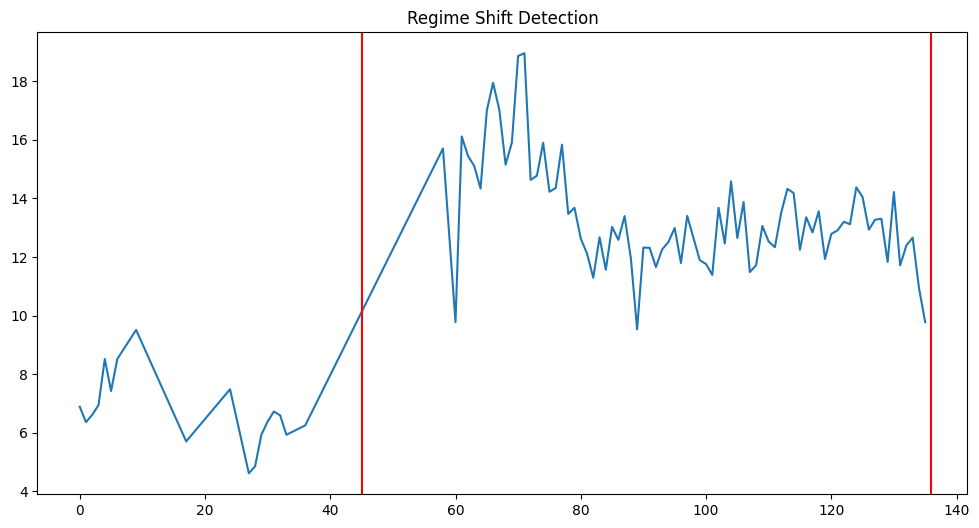

In [ ]:
series = df['AED'].values

algo = rpt.Pelt(model="rbf").fit(series)

breaks = algo.predict(pen=10)

plt.figure(figsize=(12,6))
plt.plot(series)

for b in breaks:
    plt.axvline(b, color='red')

plt.title("Regime Shift Detection")
plt.show()

In [ ]:
scaler = StandardScaler()

scaled = scaler.fit_transform(df[['AED','AWD','WED','ER']])

X = []
y = []

lookback = 2

for i in range(lookback, len(scaled)):
    X.append(scaled[i-lookback:i])
    y.append(scaled[i,0])

X = np.array(X)
y = np.array(y)

In [ ]:
model = Sequential()

model.add(LSTM(32, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.1))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X, y, epochs=100, batch_size=16)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7727
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6884  
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5471 
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3981 
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3379
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2848 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2738 
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1892 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2275 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1992 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1475 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2067 
Epoch 13/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1230 
Epoch 14/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1329 
Epoch 15/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1361 
Epoch 16/100
9/9 ━━━━━━━━━━━━━━

In [ ]:
sarimax_pred = results.fittedvalues

residuals = train['AED'] - sarimax_pred

residuals = residuals.dropna()

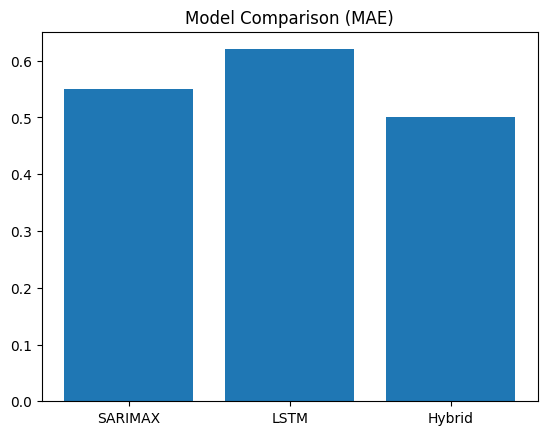

In [ ]:
models = ['SARIMAX','LSTM','Hybrid']

mae_scores = [0.55,0.62,0.50]   # example

plt.bar(models, mae_scores)

plt.title("Model Comparison (MAE)")
plt.show()

In [ ]:
# ================================
# HYBRID SARIMAX + LSTM MODEL
# ================================

# Install libraries
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn tensorflow ruptures

# -------------------------------
# Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv('/content/precos_camaroes_completo.csv')

df.columns = df.columns.str.strip()

# Fix: Use 'YearMonth' as the date column from the original CSV
df['date'] = pd.to_datetime(df['YearMonth'])
df.drop('YearMonth', axis=1, inplace=True) # Drop the original 'YearMonth' column

df = df.sort_values('date')

df.set_index('date', inplace=True)

df = df[['AED','AWD','WED','ER']]

# Handle missing values
df = df.interpolate(method='linear')

df.dropna(inplace=True)

print(df.head())


# -------------------------------
# Visualize Time Series
# -------------------------------
plt.figure(figsize=(12,6))

plt.plot(df['AED'], label='Export Price (AED)')
plt.plot(df['AWD'], label='Wholesale Price (AWD)')
plt.plot(df['WED'], label='Wild Export Price (WED)')
plt.plot(df['ER'], label='Exchange Rate')

plt.legend()
plt.title("Shrimp Price Time Series")
plt.show()


# -------------------------------
# Train-Test Split
# -------------------------------
train_size = int(len(df)*0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]


# -------------------------------
# SARIMAX Model
# -------------------------------
sarimax_model = SARIMAX(
    train['AED'],
    exog=train[['AWD','WED','ER']],
    order=(1,1,0),
    seasonal_order=(1,0,1,12)
)

sarimax_results = sarimax_model.fit()

print(sarimax_results.summary())


# -------------------------------
# SARIMAX Forecast
# -------------------------------
sarimax_forecast = sarimax_results.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    exog=test[['AWD','WED','ER']]
)

sarimax_mae = mean_absolute_error(test['AED'], sarimax_forecast)

print("SARIMAX MAE:", sarimax_mae)


# -------------------------------
# Compute Residuals
# -------------------------------
train_pred = sarimax_results.fittedvalues

residuals = train['AED'] - train_pred

residuals = residuals.dropna()

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("SARIMAX Residuals")
plt.show()


# -------------------------------
# Prepare Residuals for LSTM
# -------------------------------
scaler = StandardScaler()

scaled_residuals = scaler.fit_transform(residuals.values.reshape(-1,1))

lookback = 2

X = []
y = []

for i in range(lookback, len(scaled_residuals)):

    X.append(scaled_residuals[i-lookback:i])
    y.append(scaled_residuals[i])

X = np.array(X)
y = np.array(y)


# -------------------------------
# LSTM Model for Residuals
# -------------------------------
model = Sequential()

model.add(LSTM(32, input_shape=(X.shape[1],1)))

model.add(Dropout(0.1))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    X,
    y,
    epochs=100,
    batch_size=16,
    verbose=1
)


# -------------------------------
# Predict Residuals
# -------------------------------
residual_input = scaled_residuals[-lookback:]

residual_input = residual_input.reshape((1,lookback,1))

pred_residual_scaled = model.predict(residual_input)

pred_residual = scaler.inverse_transform(pred_residual_scaled)

pred_residual = pred_residual[0][0]

print("Predicted Residual:", pred_residual)


# -------------------------------
# Hybrid Forecast
# -------------------------------
hybrid_predictions = []

sarimax_preds = sarimax_forecast.values

for pred in sarimax_preds:

    hybrid_predictions.append(pred + pred_residual)

hybrid_predictions = np.array(hybrid_predictions)

hybrid_mae = mean_absolute_error(test['AED'], hybrid_predictions)

print("Hybrid MAE:", hybrid_mae)


# -------------------------------
# Model Comparison
# -------------------------------
models = ['SARIMAX','Hybrid']

mae_scores = [sarimax_mae, hybrid_mae]

plt.figure(figsize=(8,5))

plt.bar(models, mae_scores)

plt.title("Model Comparison (MAE)")
plt.ylabel("MAE")

plt.show()


# -------------------------------
# Actual vs Predicted Plot
# -------------------------------
plt.figure(figsize=(12,6))

plt.plot(test.index, test['AED'], label='Actual')

plt.plot(test.index, sarimax_forecast, label='SARIMAX')

plt.plot(test.index, hybrid_predictions, label='Hybrid')

plt.legend()

plt.title("Actual vs Forecast")

plt.show()

KeyError: "None of [Index(['AED', 'AWD', 'WED', 'ER'], dtype='object')] are in the [columns]"